In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Decomposition Analysis: PCA, ICA, and Eigenmodes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/advanced_decomposition.ipynb)

This tutorial covers **Principal Component Analysis (PCA)** and **Independent Component Analysis (ICA)** using `TimeSeriesMatrix`.

Both methods are available as high-level methods on `TimeSeriesMatrix` via `pca()` / `ica()`, wrapping scikit-learn internally.

**Use cases:**
- PCA: dimensionality reduction, decorrelation of correlated sensor channels
- ICA: blind source separation (BSS), e.g., separating physical signals from environmental noise

**Legacy migration note:**  
If your code used `sklearn.decomposition.PCA` or `sklearn.decomposition.FastICA` directly, you can replace them with `matrix.pca()` and `matrix.ica()`.  
See the [Migration Guide for GWpy Users](../gwexpy_for_gwpy_users_en.md) and [GWpy Difference API Index](../gwpy_added_api_index_en.md) for before/after migration examples.

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u

from gwexpy.timeseries import TimeSeriesMatrix

## 1. Prepare Synthetic Multi-channel Data

We simulate a realistic scenario:  
- Two **hidden sources**: a 10 Hz sine wave and broadband noise
- Four **observed channels**: linear mixtures of the hidden sources

This mirrors real-world scenarios in gravitational-wave detectors where physical signals are mixed across multiple sensor channels.

TimeSeriesMatrix shape: (4, 1, 8192)


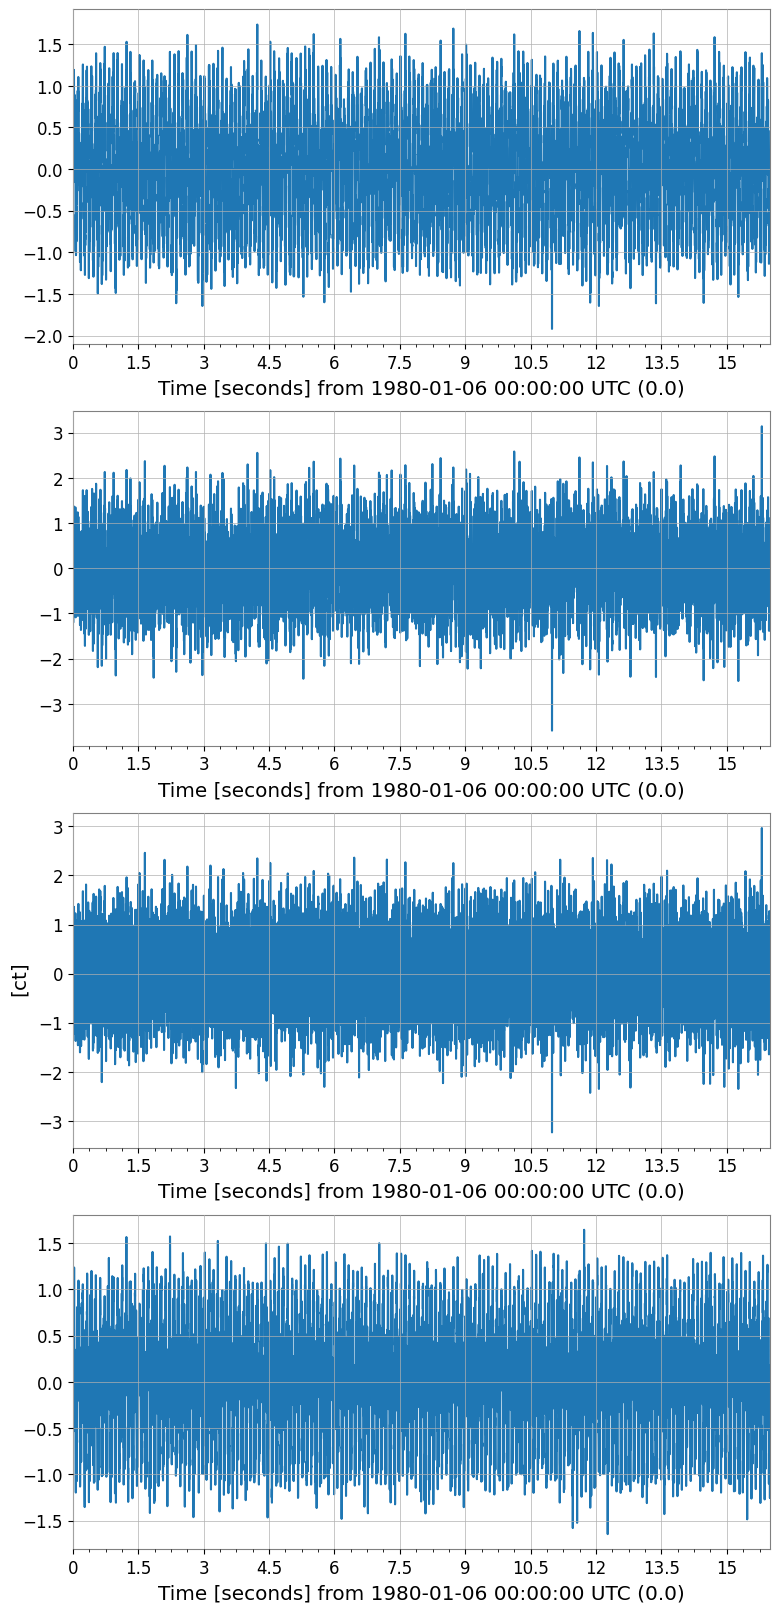

In [3]:
rng = np.random.default_rng(42)

fs = 512      # sample rate [Hz]
T  = 16.0     # duration [s]
n  = int(fs * T)
t  = np.arange(n) / fs

# Two independent source signals
src1 = np.sin(2 * np.pi * 10.0 * t)                   # 10 Hz tone
src2 = rng.normal(0, 1, n)                              # broadband noise
src3 = np.sin(2 * np.pi * 40.0 * t + 0.7)             # 40 Hz tone

# Mixing matrix (4 observed channels from 3 sources)
A = np.array([
    [0.8,  0.3,  0.1],
    [0.4,  0.7,  0.2],
    [0.2,  0.5,  0.9],
    [0.6, -0.2,  0.5],
])

sources = np.stack([src1, src2, src3], axis=0)   # (3, n)
mixed   = A @ sources                             # (4, n)

# Add small instrument noise
mixed += 0.05 * rng.normal(0, 1, mixed.shape)

# Build TimeSeriesMatrix (4 channels × 1 col × n samples)
dt = (1 / fs) * u.s
t0 = 0 * u.s

data_3d = mixed[:, np.newaxis, :]   # (4, 1, n)

tsm = TimeSeriesMatrix(
    data_3d,
    dt=dt,
    t0=t0,
    units=np.full((4, 1), u.ct),
)
tsm.channel_names = [f"CH{i}" for i in range(4)]

print("TimeSeriesMatrix shape:", tsm.shape)   # (4, 1, 8192)
tsm.plot(subplots=True, xscale="seconds");

## 2. PCA – Dimensionality Reduction

`TimeSeriesMatrix.pca()` returns the score matrix and, optionally, a `PCAResult` object containing the fitted model.

PCA score shape: (2, 1, 8192)
Explained variance ratio: [0.68552389 0.18734173]


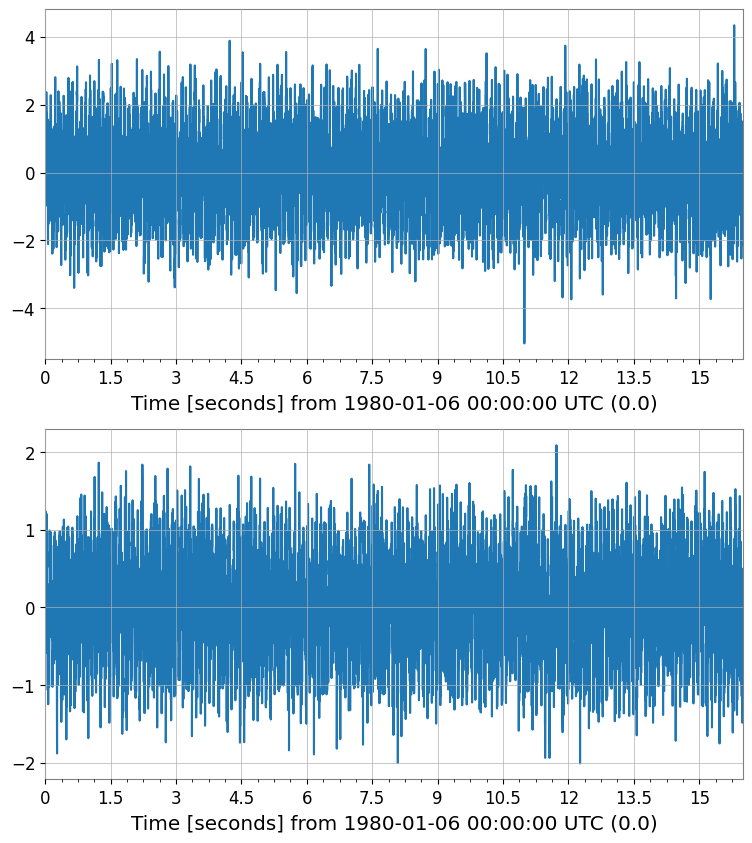

In [4]:
# Fit PCA – keep 2 principal components out of 4 channels
pca_scores, pca_res = tsm.pca(n_components=2, return_model=True)

print("PCA score shape:", pca_scores.shape)           # (2, 1, n)
print("Explained variance ratio:", pca_res.explained_variance_ratio)

pca_scores.plot(subplots=True, xscale="seconds");

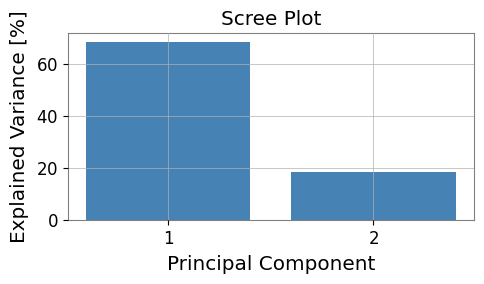

In [5]:
# Visualize explained variance (scree plot)
fig, ax = plt.subplots(figsize=(5, 3))

evr = pca_res.explained_variance_ratio
ax.bar(range(1, len(evr) + 1), evr * 100, color="steelblue")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance [%]")
ax.set_title("Scree Plot")
ax.set_xticks(range(1, len(evr) + 1))
plt.tight_layout()

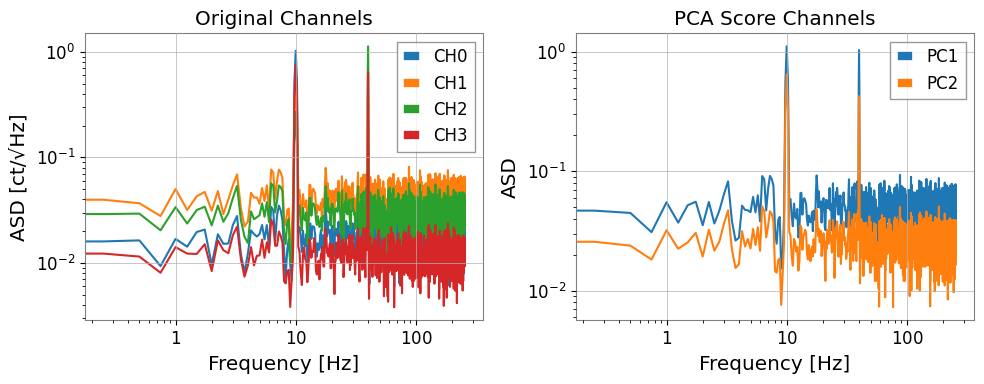

In [6]:
# Compare ASD of original channels vs PC scores
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

asd_orig = tsm.asd(fftlength=4, overlap=0.5)
for i in range(asd_orig.shape[0]):
    axes[0].loglog(
        asd_orig[i, 0].frequencies.value,
        asd_orig[i, 0].value,
        label=f"CH{i}",
    )
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("ASD [ct/√Hz]")
axes[0].set_title("Original Channels")
axes[0].legend()

asd_pca = pca_scores.asd(fftlength=4, overlap=0.5)
for i in range(asd_pca.shape[0]):
    axes[1].loglog(
        asd_pca[i, 0].frequencies.value,
        asd_pca[i, 0].value,
        label=f"PC{i+1}",
    )
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("ASD")
axes[1].set_title("PCA Score Channels")
axes[1].legend()

plt.tight_layout()

## 3. ICA – Blind Source Separation

`TimeSeriesMatrix.ica()` runs FastICA and returns a source matrix.

Unlike PCA (which finds directions of maximum variance), ICA finds statistically independent sources — making it more suitable for separating physically distinct noise contributions.

ICA source shape: (3, 1, 8192)


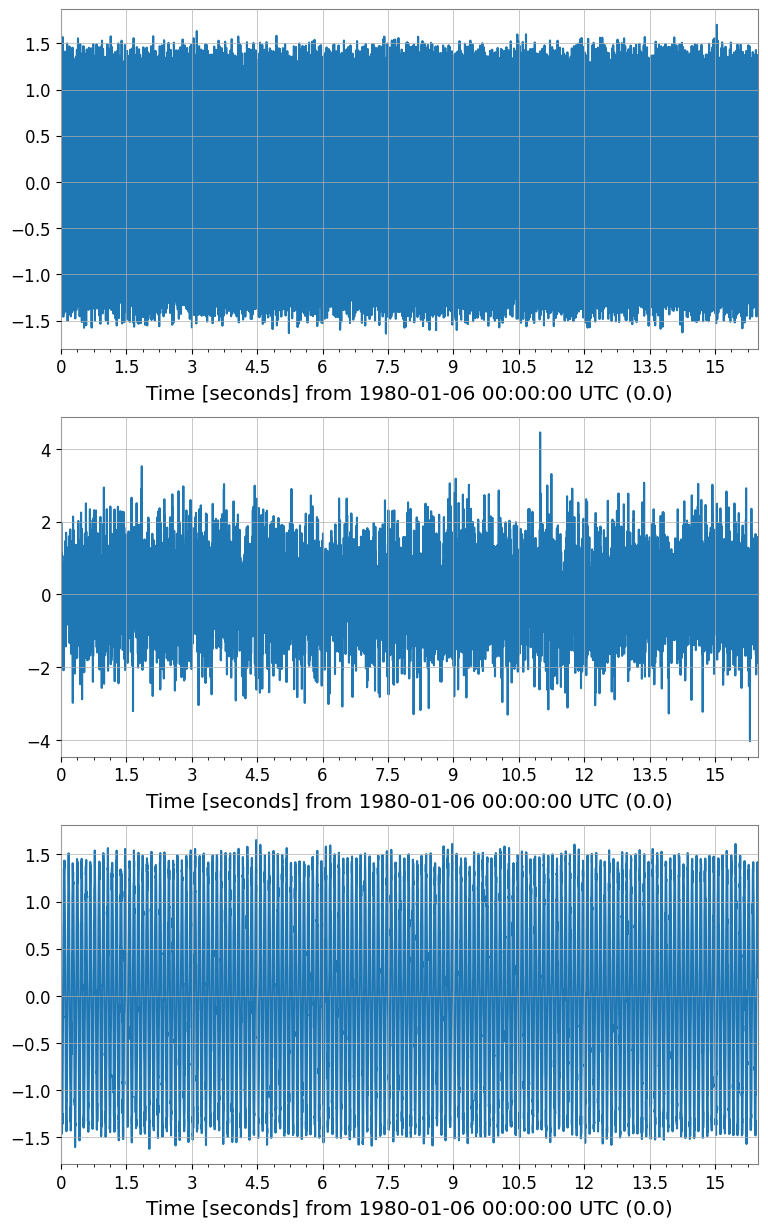

In [7]:
# Fit ICA – recover 3 independent components
ica_sources = tsm.ica(n_components=3, random_state=0)

print("ICA source shape:", ica_sources.shape)   # (3, 1, n)

ica_sources.plot(subplots=True, xscale="seconds");

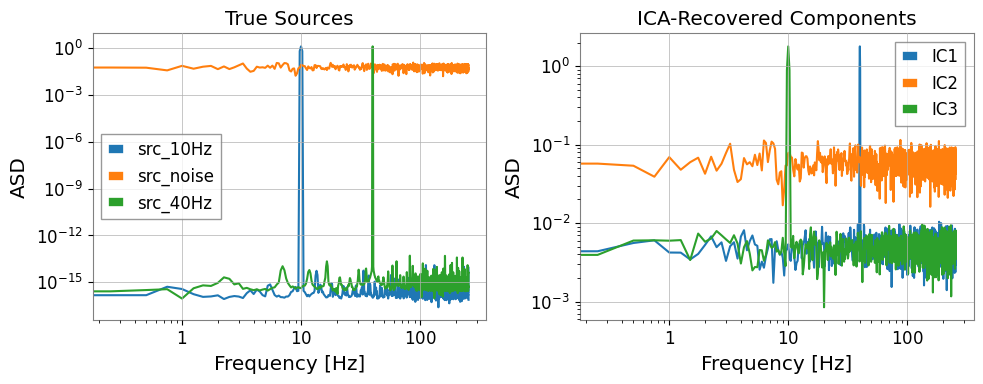

In [8]:
# Compare ICA sources vs. known sources in frequency domain
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# True sources (for reference)
src_3d = np.stack([src1, src2, src3], axis=0)[:, np.newaxis, :]  # (3,1,n)
tsm_src = TimeSeriesMatrix(src_3d, dt=dt, t0=t0)
tsm_src.channel_names = ["src_10Hz", "src_noise", "src_40Hz"]
asd_src = tsm_src.asd(fftlength=4, overlap=0.5)

for i in range(3):
    axes[0].loglog(
        asd_src[i, 0].frequencies.value,
        asd_src[i, 0].value,
        label=tsm_src.channel_names[i],
    )
axes[0].set_title("True Sources")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel("ASD")
axes[0].legend()

asd_ica = ica_sources.asd(fftlength=4, overlap=0.5)
for i in range(asd_ica.shape[0]):
    axes[1].loglog(
        asd_ica[i, 0].frequencies.value,
        asd_ica[i, 0].value,
        label=f"IC{i+1}",
    )
axes[1].set_title("ICA-Recovered Components")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("ASD")
axes[1].legend()

plt.tight_layout()

## 4. Preprocessing: Standardization and Whitening

ICA (and PCA) require data to be scaled appropriately. `TimeSeriesMatrix` provides built-in preprocessing:

| Method | Description |
|--------|-------------|
| `.standardize(method='zscore')` | Zero mean, unit variance per channel |
| `.standardize(method='robust')` | Median / MAD scaling (robust to outliers) |
| `.whiten_channels()` | PCA whitening – decorrelates channels |

The `pca()` and `ica()` methods accept a `scale` parameter to apply these internally.

In [9]:
# Manual preprocessing pipeline
tsm_z = tsm.standardize(method='zscore')

print("Mean  ≈ 0:", np.allclose(tsm_z.value.mean(axis=-1), 0, atol=1e-10))
print("Std   ≈ 1:", np.allclose(tsm_z.value.std(axis=-1),  1, atol=0.01))

# ICA with internal z-score scaling
ica_scaled = tsm.ica(n_components=3, scale='zscore', random_state=0)
print("ICA (with zscore) shape:", ica_scaled.shape)

# PCA with robust scaling
pca_robust, pca_res2 = tsm.pca(n_components=2, scale='robust', return_model=True)
print("PCA (robust) EVR:", pca_res2.explained_variance_ratio)

Mean  ≈ 0: True
Std   ≈ 1: True
ICA (with zscore) shape: (3, 1, 8192)
PCA (robust) EVR: [0.44248267 0.37626797]


## 5. Handling Missing Values (NaN)

Real detector data often contains gaps. Use `nan_policy='impute'` to handle NaNs before decomposition.

In [10]:
# Inject some NaN gaps (simulating data gaps)
tsm_nan = tsm.copy()
tsm_nan.value[0, 0, 100:120] = np.nan
tsm_nan.value[2, 0, 500:510] = np.nan

print("NaN count:", np.sum(np.isnan(tsm_nan.value)))

# PCA with linear interpolation of NaN gaps
pca_nanfill, _ = tsm_nan.pca(
    n_components=2,
    nan_policy='impute',
    impute_kwargs={'method': 'interpolate'},
    return_model=True,
)
print("PCA (nan impute) shape:", pca_nanfill.shape)

NaN count: 30
PCA (nan impute) shape: (2, 1, 8192)


## 6. Migration from scikit-learn

**Before (scikit-learn directly):**
```python
from sklearn.decomposition import PCA, FastICA
import numpy as np

# Raw numpy array: (n_samples, n_features)
X = data.reshape(n_channels, n_samples).T  # (n_samples, n_channels)

pca = PCA(n_components=2)
scores = pca.fit_transform(X)           # (n_samples, 2)

ica = FastICA(n_components=3, random_state=0)
sources = ica.fit_transform(X)          # (n_samples, 3)
```

**After (gwexpy):**
```python
# TimeSeriesMatrix preserves dt/t0/units throughout
pca_scores, pca_res = tsm.pca(n_components=2, return_model=True)
ica_sources          = tsm.ica(n_components=3, random_state=0)
```

The gwexpy API automatically:
- Preserves time axis (`dt`, `t0`, `times`) in the output matrix
- Keeps unit metadata
- Provides direct plotting via `.plot()`
- Handles NaN policies and scaling internally

## Summary

| Method | Key parameters | Output |
|--------|---------------|--------|
| `tsm.pca(n_components, return_model=True)` | `scale`, `nan_policy`, `whiten` | `(scores_matrix, PCAResult)` |
| `tsm.ica(n_components, random_state)` | `scale`, `nan_policy`, `prewhiten`, `fun` | `sources_matrix` |

Both methods return `TimeSeriesMatrix` objects, so all downstream operations (`.plot()`, `.asd()`, `.coherence()`) work without any additional conversion.

**See also:**
- [TimeSeriesMatrix Tutorial](matrix_timeseries.ipynb)
- [ML Preprocessing Pipeline](case_ml_preprocessing.ipynb)